In [1]:
# Keras: biblioteca de alto nível para construção e treinamento de redes neurais
# Atualmente integrada ao TensorFlow como interface principal
import keras

# applications  → modelos pré-treinados prontos para uso
#                 ex: VGG16, ResNet50, MobileNet, EfficientNet, etc.
# preprocessing → utilitários para preparar dados antes de alimentar o modelo
#                 ex: redimensionar imagens, normalizar pixels, aplicar augmentation
from keras import applications, preprocessing

# numpy: biblioteca para operações matemáticas com arrays e matrizes
# usada para manipular os dados de entrada e saída do modelo
import numpy as np

# pyplot: interface do matplotlib para criação de gráficos e visualização de imagens
from matplotlib import pyplot as plt

I0000 00:00:1773703352.102800   25148 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Carrega o modelo ResNet50 com pesos pré-treinados no ImageNet
#
# ResNet50:
#   → Rede neural profunda com 50 camadas, criada pela Microsoft em 2015
#   → Introduziu os "blocos residuais" (skip connections): conexões que pulam camadas,
#     resolvendo o problema de gradientes que desaparecem em redes muito profundas
#   → É um dos modelos mais usados como base para transfer learning
#
# weights='imagenet':
#   → Carrega pesos já treinados no dataset ImageNet
#   → ImageNet: dataset com 1.2 milhão de imagens em 1000 categorias diferentes
#     (cachorros, carros, instrumentos, animais, objetos cotidianos, etc.)
#   → Alternativa: weights=None → inicializa com pesos aleatórios (treino do zero)
#
# Por que usar pesos pré-treinados?
#   → Transfer learning: o modelo já "sabe" reconhecer padrões visuais gerais
#     (bordas, texturas, formas, objetos) aprendidos com milhões de imagens
#   → Economiza tempo e dados: em vez de treinar do zero, aproveitamos esse
#     conhecimento e adaptamos para o nosso problema específico
model = applications.resnet50.ResNet50(weights='imagenet')

I0000 00:00:1773703361.662351   25148 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9704 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:05:00.0, compute capability: 8.6


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
# Caminho para a imagem que será classificada pelo modelo
img_path = 'teste1.jpeg'

# Carrega a imagem do disco e já a redimensiona para o tamanho esperado pelo ResNet50
# target_size=(224, 224):
#   → O ResNet50 foi treinado com imagens de 224x224 pixels — tamanho obrigatório na entrada
#   → Imagens maiores ou menores são redimensionadas automaticamente
#   → O resultado é um objeto PIL (Python Imaging Library), ainda não é um array numérico
img = preprocessing.image.load_img(img_path, target_size=(224, 224))

# Exibe informações do objeto PIL: modo de cor (RGB), tamanho (224x224), etc.
# ex: <PIL.Image.Image image mode=RGB size=224x224 at 0x...>
print(img)

# Converte o objeto PIL em um array NumPy de shape (224, 224, 3)
#   → 224: altura em pixels
#   → 224: largura em pixels
#   → 3  : canais de cor (R, G, B) com valores entre 0.0 e 255.0
x = preprocessing.image.img_to_array(img)

# x.shape → confirma as dimensões do array: esperado (224, 224, 3)
# x[:1]   → exibe a primeira linha de pixels (224 pixels com 3 valores RGB cada)
#          → útil para inspecionar os valores brutos antes da normalização
print(x.shape, x[:1])

<PIL.Image.Image image mode=RGB size=224x224 at 0x7A45A89DF6D0>
(224, 224, 3) [[[ 99. 135.  61.]
  [ 99. 135.  61.]
  [ 64.  99.  31.]
  [ 64.  99.  31.]
  [115. 144.  90.]
  [215. 244. 190.]
  [215. 244. 190.]
  [194. 222. 161.]
  [194. 222. 161.]
  [115. 146.  78.]
  [115. 146.  78.]
  [ 64.  96.  31.]
  [ 54.  91.  22.]
  [ 54.  91.  22.]
  [ 68. 109.  39.]
  [ 68. 109.  39.]
  [ 66. 112.  39.]
  [ 66. 112.  39.]
  [ 62. 113.  38.]
  [ 55. 109.  25.]
  [ 55. 109.  25.]
  [ 52. 108.   7.]
  [ 52. 108.   7.]
  [ 52. 109.   2.]
  [ 52. 109.   2.]
  [ 81. 138.  35.]
  [ 75. 129.  35.]
  [ 75. 129.  35.]
  [ 53.  97.  18.]
  [ 53.  97.  18.]
  [ 43.  87.  12.]
  [ 40.  87.   9.]
  [ 40.  87.   9.]
  [ 47.  99.  16.]
  [ 47.  99.  16.]
  [ 55. 109.  25.]
  [ 55. 109.  25.]
  [ 64. 120.  31.]
  [ 71. 128.  34.]
  [ 71. 128.  34.]
  [ 71. 128.  34.]
  [ 71. 128.  34.]
  [117. 170.  82.]
  [117. 170.  82.]
  [136. 189. 101.]
  [ 99. 148.  57.]
  [ 99. 148.  57.]
  [ 58. 108.   9.]
  [ 58. 10

In [4]:
# O ResNet50 espera um batch de imagens como entrada, não uma imagem isolada
# shape atual:  (224, 224, 3)   → uma imagem
# shape esperado: (1, 224, 224, 3) → batch com 1 imagem
#
# np.expand_dims adiciona uma nova dimensão no eixo especificado
# axis=0 → insere a dimensão do batch na primeira posição
# ex: (224, 224, 3) → (1, 224, 224, 3)
x = np.expand_dims(x, axis=0)

# x.shape → confirma o novo shape: esperado (1, 224, 224, 3)
# x[:1]   → exibe o primeiro (e único) elemento do batch
#          → equivalente a x[0], mas mantém a dimensão do batch no resultado
print(x.shape, x[:1])

(1, 224, 224, 3) [[[[ 99. 135.  61.]
   [ 99. 135.  61.]
   [ 64.  99.  31.]
   ...
   [182. 176. 154.]
   [161. 156. 137.]
   [161. 156. 137.]]

  [[ 99. 135.  61.]
   [ 99. 135.  61.]
   [ 64.  99.  31.]
   ...
   [182. 176. 154.]
   [161. 156. 137.]
   [161. 156. 137.]]

  [[ 99. 135.  61.]
   [ 99. 135.  61.]
   [ 64.  99.  31.]
   ...
   [182. 176. 154.]
   [161. 156. 137.]
   [161. 156. 137.]]

  ...

  [[ 86. 118.  51.]
   [ 86. 118.  51.]
   [119. 155.  83.]
   ...
   [127. 186. 128.]
   [135. 195. 135.]
   [135. 195. 135.]]

  [[ 86. 118.  51.]
   [ 86. 118.  51.]
   [119. 155.  83.]
   ...
   [127. 186. 128.]
   [135. 195. 135.]
   [135. 195. 135.]]

  [[ 86. 118.  51.]
   [ 86. 118.  51.]
   [119. 155.  83.]
   ...
   [127. 186. 128.]
   [135. 195. 135.]
   [135. 195. 135.]]]]


In [5]:
# Aplica o pré-processamento específico do ResNet50 nos pixels da imagem
# Cada arquitetura foi treinada com uma normalização própria — usar a errada
# prejudica as previsões mesmo que o modelo esteja correto
#
# O que preprocess_input faz no ResNet50:
#   → Converte de RGB para BGR (formato que o ResNet50 espera)
#   → Subtrai a média de cada canal calculada no ImageNet:
#       R: 103.939 / G: 116.779 / B: 123.68
#   → Resultado: pixels deixam de ser [0, 255] e passam a ter valores negativos e positivos
x = applications.resnet.preprocess_input(x)

# Confirma que o shape não mudou (apenas os valores dos pixels foram alterados)
# x[:1] → permite ver que os valores agora são bem diferentes de [0, 255]
print(x.shape, x[:1])

# Passa a imagem pelo ResNet50 e obtém as probabilidades brutas
# preds: array de shape (1, 1000) — uma probabilidade para cada classe do ImageNet
preds = model.predict(x)

# Exibe o array bruto: 1000 valores de probabilidade entre 0.0 e 1.0 que somam 1.0
# Difícil de interpretar diretamente — por isso usamos decode_predictions abaixo
print('Raw predictions:', preds[:1])

# Converte o array de 1000 probabilidades em rótulos legíveis
# top=3 → retorna apenas as 3 classes com maior probabilidade
# Resultado: lista de tuplas (id_classe, nome_classe, probabilidade)
# ex: [('n02099712', 'Labrador_retriever', 0.78), ...]
decoded_preds = applications.resnet50.decode_predictions(preds, top=3)

# [:1] → exibe as previsões da primeira (e única) imagem do batch
print('Decoded predictions:', decoded_preds[:1])

(1, 224, 224, 3) [[[[-42.939003   18.221     -24.68     ]
   [-42.939003   18.221     -24.68     ]
   [-72.939     -17.779     -59.68     ]
   ...
   [ 50.060997   59.221      58.32     ]
   [ 33.060997   39.221      37.32     ]
   [ 33.060997   39.221      37.32     ]]

  [[-42.939003   18.221     -24.68     ]
   [-42.939003   18.221     -24.68     ]
   [-72.939     -17.779     -59.68     ]
   ...
   [ 50.060997   59.221      58.32     ]
   [ 33.060997   39.221      37.32     ]
   [ 33.060997   39.221      37.32     ]]

  [[-42.939003   18.221     -24.68     ]
   [-42.939003   18.221     -24.68     ]
   [-72.939     -17.779     -59.68     ]
   ...
   [ 50.060997   59.221      58.32     ]
   [ 33.060997   39.221      37.32     ]
   [ 33.060997   39.221      37.32     ]]

  ...

  [[-52.939003    1.2210007 -37.68     ]
   [-52.939003    1.2210007 -37.68     ]
   [-20.939003   38.221      -4.6800003]
   ...
   [ 24.060997   69.221       3.3199997]
   [ 31.060997   78.221      11.32     ]

I0000 00:00:1773703372.598491   25348 service.cc:153] XLA service 0x7a44b0066b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773703372.598524   25348 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773703372.644175   25348 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773703372.998519   25348 cuda_dnn.cc:461] Loaded cuDNN version 92000


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Raw predictions: [[1.93221823e-07 1.23384652e-07 2.02346473e-09 9.54023527e-09
  2.37307241e-09 2.48310272e-07 3.00676000e-08 9.39026359e-06
  1.22897006e-06 7.59952954e-08 1.98601151e-06 2.59425724e-06
  5.11900495e-08 3.18796403e-08 6.56521706e-07 2.64199144e-07
  1.17481768e-07 2.64201901e-07 4.82040328e-08 5.12434859e-08
  5.62991715e-08 2.65530457e-06 3.28904193e-08 2.70421140e-07
  8.04831529e-07 1.58577268e-06 2.59484614e-06 4.10140046e-07
  9.08851348e-07 3.17938387e-08 1.56804603e-07 4.38815874e-07
  4.71288786e-07 6.92653757e-09 4.96659425e-08 3.43236798e-06
  3.71949841e-06 1.65031918e-06 1.17945467e-06 4.17527531e-07
  3.00753015e-07 7.01834551e-07 9.65321263e-08 3.41438886e-06
  5.07534537e-07 4.14378661e-07 6.40927951e-08 3.23126369e-06
  2.78519909e-08 4.00095281e-08 2.36447129e-08 3.66968322e-07
  2.89234634e-07 6.53978987e-07 1.23174217e-07 3.80232237e-08
  8.35872186e-07 8.31938323e-08 5.77786743e-08 7.01810507e-07
  3.36224360e-07 

I0000 00:00:1773703376.338730   25348 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Decoded predictions: [[('n02279972', 'monarch', np.float32(0.9852431)), ('n02277742', 'ringlet', np.float32(0.003948652)), ('n02264363', 'lacewing', np.float32(0.0035445618))]]


Top 3 predictions:
	1. monarch: 0.99
	2. ringlet: 0.00
	3. lacewing: 0.00


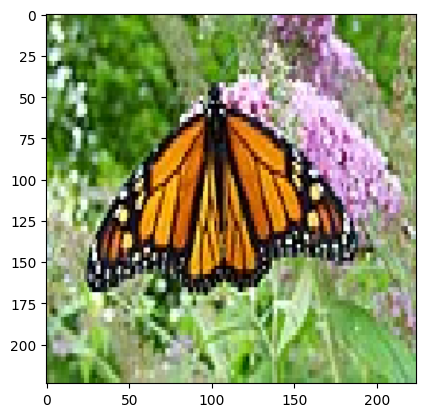

In [6]:
# Exibe a imagem original (objeto PIL, ainda em RGB)
# Como não passamos cmap='gray', o matplotlib exibe em cores normais
plt.imshow(img)

# decoded_preds tem shape (1, 3) — lista de batches, cada um com top 3 previsões
# [0] acessa as previsões da primeira (e única) imagem do batch
# resultado: lista com 3 tuplas (class_id, class_name, probability)
decoded_preds_first = decoded_preds[0]

print('Top 3 predictions:')

# Itera sobre as 3 melhores previsões desempacotando cada tupla em 3 variáveis:
#   class_id    → identificador interno do ImageNet  ex: 'n02099712'
#   class_name  → nome legível da classe             ex: 'Labrador_retriever'
#   probability → confiança do modelo (0.0 a 1.0)   ex: 0.78
# enumerate(...) adiciona o índice i para numerar as previsões (1., 2., 3.)
for i, (class_id, class_name, probability) in enumerate(decoded_preds_first):
    # :.2f → formata a probabilidade com 2 casas decimais  ex: 0.78
    # i+1  → começa a contagem em 1 em vez de 0
    print(f'\t{i+1}. {class_name}: {probability:.2f}')

# Processo direto para nova imagem

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Top 3 predictions:
	 1. sports_car: 0.94
	 2. racer: 0.05
	 3. convertible: 0.00


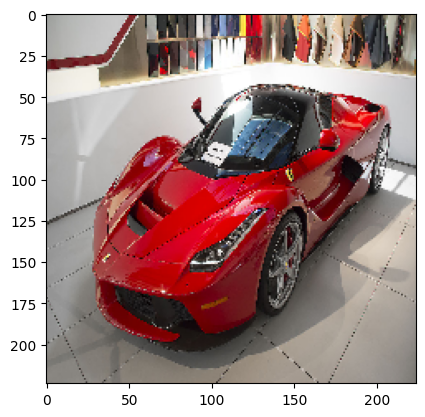

In [8]:
# Nova imagem a ser classificada
img_path = 'teste2.jpeg'

# Carrega e redimensiona para 224x224 (tamanho obrigatório do ResNet50)
img = preprocessing.image.load_img(img_path, target_size=(224, 224))

# Pipeline de pré-processamento encadeado (mesmo processo do teste anterior,
# mas agora usando uma variável intermediária 'processed_img' em vez de 'x',
# mantendo 'img' intacto para exibição com plt.imshow() se necessário)

# Converte o objeto PIL para array NumPy: (224, 224, 3)
processed_img = preprocessing.image.img_to_array(img)

# Adiciona a dimensão do batch: (224, 224, 3) → (1, 224, 224, 3)
processed_img = np.expand_dims(processed_img, axis=0)

# Aplica a normalização do ResNet50: subtrai a média por canal do ImageNet
processed_img = applications.resnet.preprocess_input(processed_img)

# Obtém o array bruto de probabilidades: shape (1, 1000)
preds = model.predict(processed_img)

# Decodifica e já acessa o [0] diretamente — mais conciso que o exemplo anterior
# Resultado: lista com 3 tuplas (class_id, class_name, probability)
decoded_preds = applications.resnet50.decode_predictions(preds, top=3)[0]

plt.imshow(img)

print('Top 3 predictions:')
for i, (class_id, class_name, probability) in enumerate(decoded_preds):
    print(f'\t {i+1}. {class_name}: {probability:.2f}')